# Zomato Restaurant Data Analysis

## Business Problem

The objective of this project is to analyze restaurant and customer preference data from Zomato to identify:

- Customer engagement patterns
- Popular cuisines and restaurant categories
- Pricing trends and affordability ranges
- Factors influencing restaurant ratings and votes
- Relationship between pricing, ratings, and customer interaction

The insights generated from this analysis can help restaurants and food delivery platforms optimize pricing strategies, improve customer engagement, and understand dining behavior.

# Dataset Overview

This dataset contains restaurant-related information including:

- Restaurant names
- Cuisine categories
- Ratings
- Votes
- Approximate cost
- Delivery and dining information
- Bestseller tags

The project focuses on extracting actionable business insights using exploratory data analysis.

# Import Libraries

# Data Loading

The dataset is loaded using Pandas for analysis and preprocessing.

In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Getting started.pdf',
 'UID (1).pdf',
 'UID.pdf',
 'cv.docx - Google Docs (1).pdf',
 'cv.docx - Google Docs.pdf',
 'Tutor coach prework_Kumari Hunney (1).docx',
 'Tutor coach prework_Kumari Hunney.docx',
 'zomato_dataset.csv',
 'mata dungeshwari hills.pdf',
 'Ahilya sthaan.pdf',
 'DS Admission Offer .pdf',
 'Saved from Chrome',
 'Untitled spreadsheet (2).gsheet',
 'df_arabica_clean.gsheet',
 'Colab Notebooks',
 'Resume.gdoc',
 'Adidas Sales - Data Sales Adidas.csv',
 'Untitled spreadsheet (1).gsheet',
 'Untitled spreadsheet.gsheet',
 'zomato_dataset.csv.zip']

In [ ]:
zip_path = '/content/drive/MyDrive/zomato_dataset.csv.zip'
!unzip -o "$zip_path" -d /content/drive/MyDrive/

Archive:  /content/drive/MyDrive/zomato_dataset.csv.zip
  inflating: /content/drive/MyDrive/zomato_dataset.csv  


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/zomato_dataset.csv'
df = pd.read_csv(csv_path, encoding='latin-1')

df.head()

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


In [ ]:
df.head()
df.shape
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant Name  123657 non-null  object 
 1   Dining Rating    91421 non-null   float64
 2   Delivery Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  object 
 6   Place Name       123657 non-null  object 
 7   City             123657 non-null  object 
 8   Item Name        123657 non-null  object 
 9   Best Seller      27942 non-null   object 
 10  Votes            123657 non-null  int64  
 11  Prices           123657 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 11.3+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant Name,123657,826,McDonald's,2059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dining Rating,91421.0,NaN,NaN,NaN,3.822264,0.408693,2.5,3.6,3.9,4.1,4.8
Delivery Rating,122377.0,NaN,NaN,NaN,3.963184,0.2459,2.5,3.8,4.0,4.1,4.6
Dining Votes,123657.0,NaN,NaN,NaN,152.729858,232.214061,0.0,0.0,30.0,217.0,997.0
Delivery Votes,123657.0,NaN,NaN,NaN,115.763725,243.970828,0.0,0.0,0.0,23.0,983.0
Cuisine,123657,48,Beverages,39441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Place Name,123657,324,C Scheme,3775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,123657,17,Hyderabad,15613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Name,123657,55693,Veg Fried Rice,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Best Seller,27942,13,BESTSELLER,16992,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Removing Duplicate Records
Duplicate entries are removed to avoid biased analysis.

In [ ]:
df.isna().sum()
df.duplicated().sum()

np.int64(22127)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df[df['Dining Rating'].notna()]

In [ ]:
df['Prices'] = (
    df['Prices']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

In [ ]:
df.columns = df.columns.str.strip()
df['num_cuisines'] = df['Cuisine'].astype(str).str.split(',').apply(len)

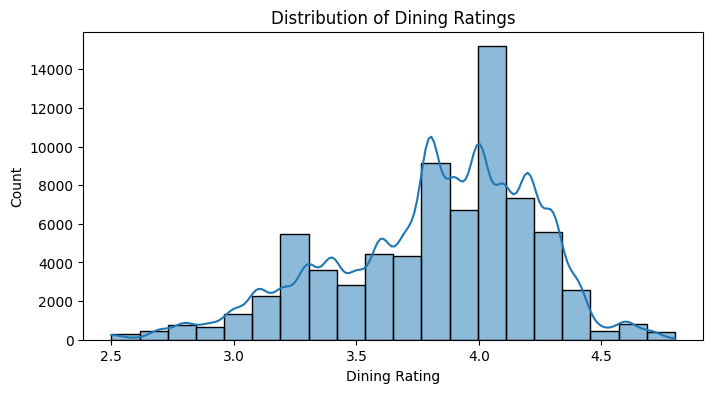

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['Dining Rating'], bins=20, kde=True)
plt.title("Distribution of Dining Ratings")
plt.show()

plt.tight_layout()

#Insights: Distribution of Dining Ratings

The majority of dining ratings fall within the
3.0 to 4.3 range, indicating generally positive customer satisfaction across most restaurants.

Very few restaurants receive ratings below 3.0, suggesting that extremely poor dining experiences are uncommon.

Similarly, ratings above 4.5 are rare, showing
that truly exceptional dining experiences are limited.

The KDE curve shows a slight right-skew, meaning customers tend to give higher ratings more often than lower ones.

The narrow concentration of ratings suggests that dining experiences are fairly consistent across the dataset, with most restaurants delivering comparable quality.

The cluster around mid-high ratings implies a competitive market, where restaurants need differentiation through service, ambiance, or menu innovation to stand out.

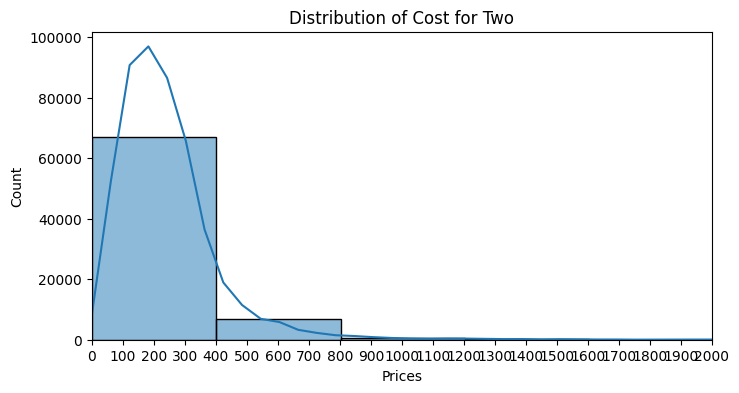

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['Prices'], bins=30, kde=True)
plt.title("Distribution of Cost for Two")
plt.xlabel("Prices")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
plt.xlim(0, 2000)

plt.show()

plt.tight_layout()

#Insights: Distribution of Prices

The distribution shows that most food item prices fall between ₹100 and ₹400, indicating that restaurants primarily offer affordable, budget-friendly options.

There is a clear density peak around ₹150–₹250, suggesting this is the most common price range for popular menu items.

Prices above ₹600 are significantly less frequent, suggesting that customers tend to prefer mid-range items over premium-priced ones.

The long tail extending towards ₹1500–₹2000 represents a small number of premium or specialty dishes, likely targeted at niche or high-end consumers.

The overall distribution highlights a heavily skewed pricing strategy, where the majority of items are positioned in low-to-mid price segments to maximize customer reach.

The strong clustering of prices implies that restaurants maintain consistent pricing strategies, with only a few offering high-price premium items.

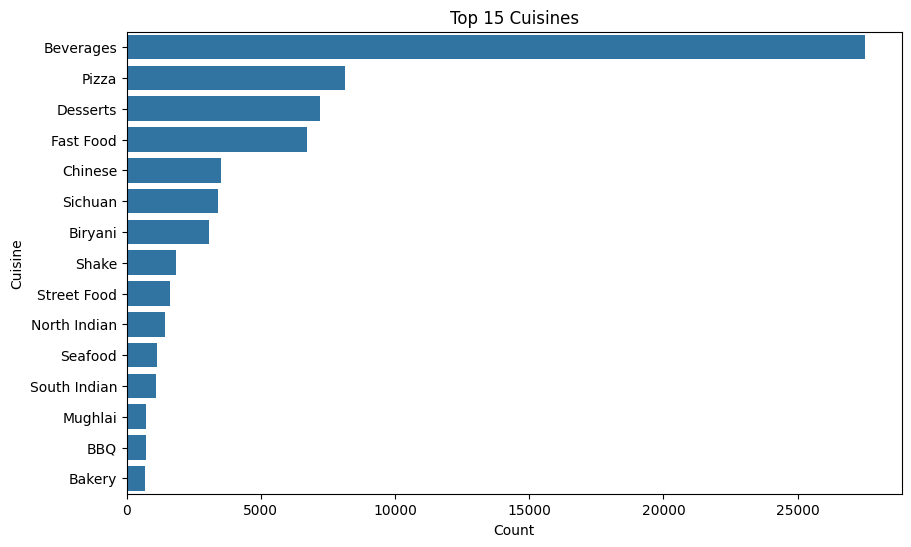

In [ ]:
from collections import Counter

cuisine_list = df['Cuisine'].dropna().str.split(',').sum()
top_cuisines = Counter([c.strip() for c in cuisine_list]).most_common(15)

import pandas as pd
top_cuisines_df = pd.DataFrame(top_cuisines, columns=['Cuisine', 'Count'])

plt.figure(figsize=(10,6))
sns.barplot(data=top_cuisines_df, x='Count', y='Cuisine')
plt.title("Top 15 Cuisines")
plt.show()

plt.tight_layout()

#Insights: Top 15 Cuisines

Beverages dominate the menu offerings by a huge margin, far exceeding all other cuisines. This indicates that drinks (tea, coffee, shakes, juices, sodas, etc.) are the most frequently listed and widely consumed category across restaurants.

The extremely large gap between Beverages and all other cuisines suggests:

High-frequency purchases

Strong customer demand

Restaurants rely on beverages as a volume driver

Beverages are likely included as add-ons, combos, or upsell items

Pizza, Desserts, and Fast Food form the next largest segments, showing that casual and quick-service food categories dominate the market after beverages.

Cuisines like Chinese, Sichuan, and Biryani also appear prominently, indicating strong customer preference for flavorful, fast-moving dishes.

Lower-frequency cuisines (Mughlai, BBQ, Bakery, etc.) might represent specialty or niche offerings, often found in fewer restaurants or limited menus.

The distribution overall shows a heavily skewed cuisine landscape, where a small number of cuisines (especially Beverages) account for the majority of the menu listings, while many other cuisines occupy smaller niche markets.

Business Insight:
Restaurants can maximize engagement and sales by:

Offering a diverse and appealing beverage menu

Bundling beverages with popular foods (pizza, fast food, desserts)

Leveraging beverages as a low-cost, high-frequency profit driver

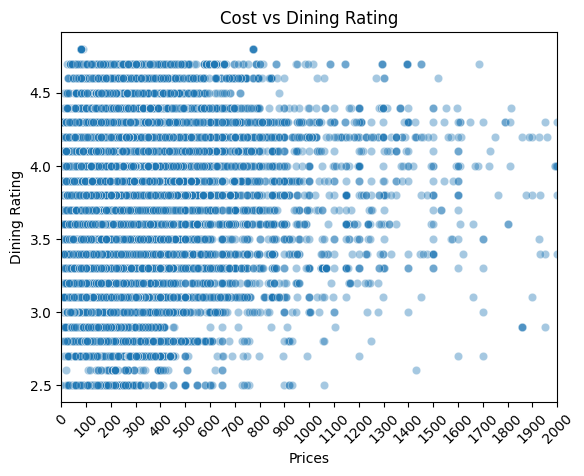

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

sns.scatterplot(x='Prices', y='Dining Rating', data=df, alpha=0.4)
plt.title("Cost vs Dining Rating")
plt.xlabel("Prices")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
plt.xlim(0, 2000)
plt.xticks(rotation=45)

plt.show()

#Insights: Cost vs Dining Rating

The scatter plot shows no strong positive relationship between price and dining rating. Both cheap and expensive items receive similar ratings, meaning higher cost does not guarantee higher customer satisfaction.

Most items priced between ₹100 and ₹600 cluster around ratings of 3.5 to 4.3, indicating that customers tend to give good ratings even for affordable options. This suggests strong value-for-money perceptions in this price range.

Premium-priced items (₹800 – ₹2000) do not consistently receive higher ratings. These points are scattered with both high and low ratings, which implies:

Premium menu items vary in quality

Customers may be more critical when paying higher prices

High price ≠ high satisfaction

The densest band of ratings appears between 3.8 – 4.2, regardless of cost. This shows that restaurant dining experiences are fairly consistent, independent of price category.

Few ratings fall below 3.0, even at lower price ranges, suggesting that low-cost items do not translate into poor ratings. Customers are generally satisfied across pricing segments.

The wide horizontal spread at each rating value indicates that price has little predictive power over dining rating. Quality, service, taste, and ambiance likely play a bigger role.

num_cuisines
1    74572
Name: count, dtype: int64


/tmp/ipython-input-700606820.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


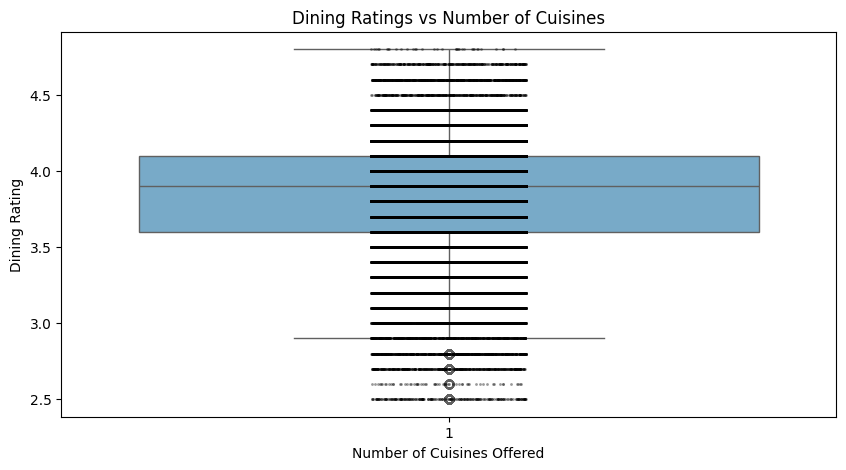

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['num_cuisines'] = df['Cuisine'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)


print(df['num_cuisines'].value_counts())


plt.figure(figsize=(10,5))
sns.boxplot(
    x='num_cuisines',
    y='Dining Rating',
    data=df,
    palette="Blues"
)


sns.stripplot(
    x='num_cuisines',
    y='Dining Rating',
    data=df,
    color='black',
    size=2,
    alpha=0.4
)

plt.title("Dining Ratings vs Number of Cuisines")
plt.xlabel("Number of Cuisines Offered")
plt.ylabel("Dining Rating")
plt.show()

plt.tight_layout()

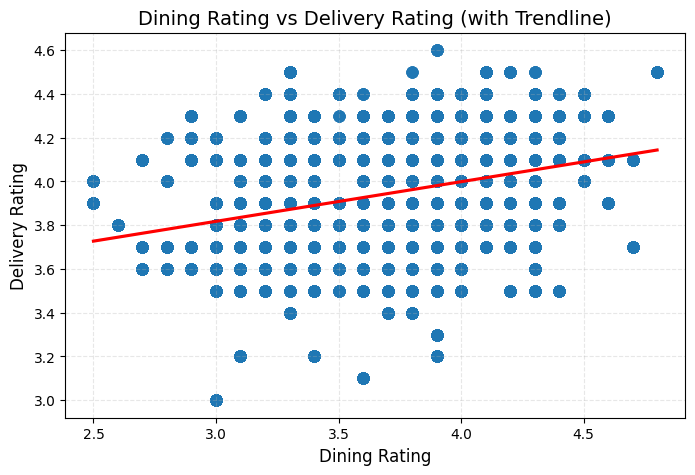

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    x='Dining Rating',
    y='Delivery Rating',
    data=df,
    scatter_kws={'alpha': 0.5, 's': 60},
    line_kws={'color': 'red'}
)

plt.title("Dining Rating vs Delivery Rating (with Trendline)", fontsize=14)
plt.xlabel("Dining Rating", fontsize=12)
plt.ylabel("Delivery Rating", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()


plt.tight_layout()

In [ ]:
correlation = df['Dining Rating'].corr(df['Delivery Rating'])
correlation


np.float64(0.314260716671034)

This shows moderate positive correlation between dining and delivery ratings.

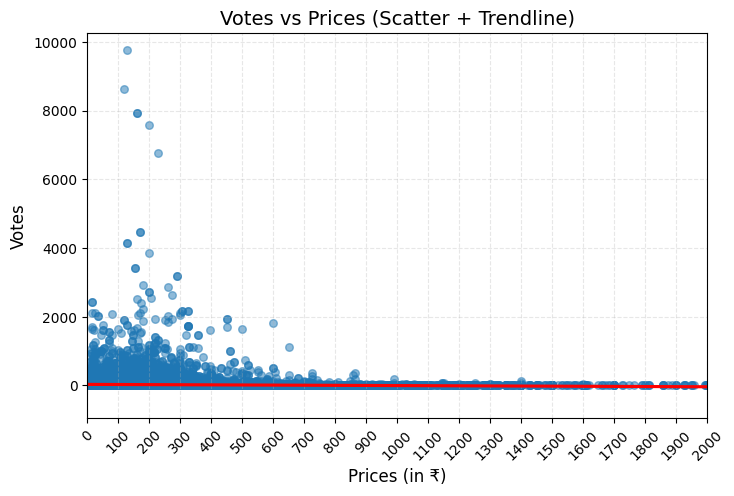

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8,5))

sns.regplot(
    x='Prices',
    y='Votes',
    data=df,
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'red'}
)

plt.title("Votes vs Prices (Scatter + Trendline)", fontsize=14)
plt.xlabel("Prices (in ₹)", fontsize=12)
plt.ylabel("Votes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
plt.xlim(0, 2000) 
plt.xticks(rotation=45)

plt.show()

plt.tight_layout()

In [ ]:
correlation_votes_prices = df['Votes'].corr(df['Prices'])
print(f"Correlation between Votes and Prices: {correlation_votes_prices}")

Correlation between Votes and Prices: -0.05364666614200421


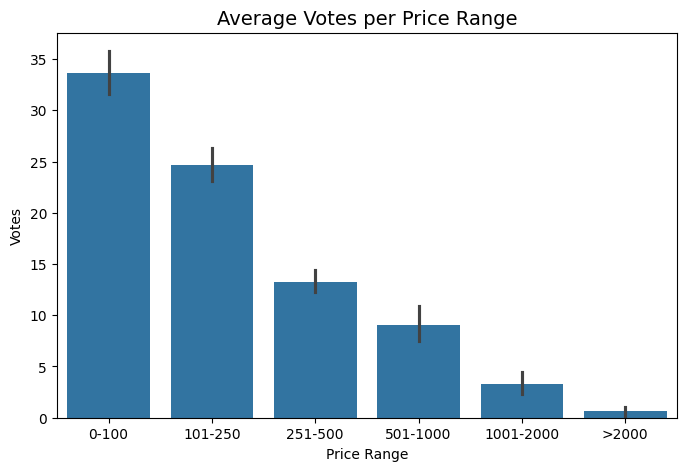

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Price Range', y='Votes', data=df, estimator='mean')
plt.title("Average Votes per Price Range", fontsize=14)
plt.show()

plt.tight_layout()

In [ ]:
bins = [0, 100, 250, 500, 1000, 2000, df['Prices'].max()]
labels = ['0-100', '101-250', '251-500', '501-1000', '1001-2000', '>2000']
df['Price Range'] = pd.cut(df['Prices'], bins=bins, labels=labels, right=True)

display(df[['Prices', 'Price Range']].head())

,Prices,Price Range
0,249.0,101-250
1,129.0,101-250
2,189.0,101-250
3,189.0,101-250
4,205.0,101-250


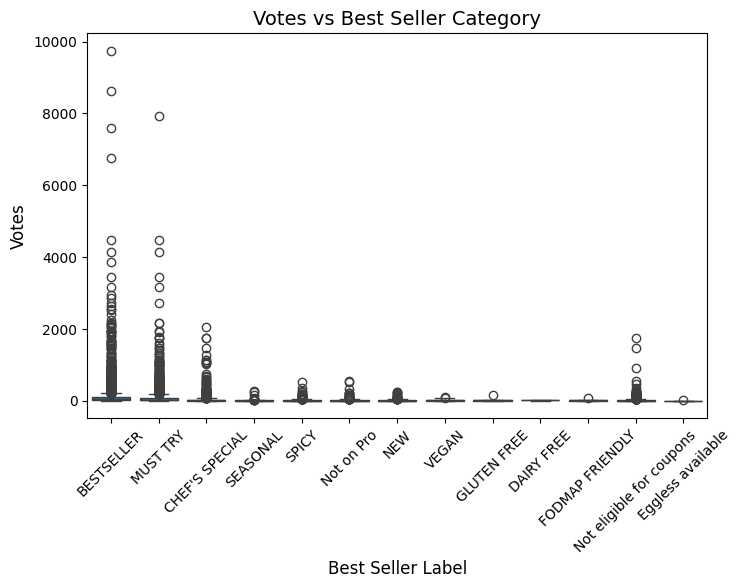

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Best Seller', y='Votes', data=df)
plt.title("Votes vs Best Seller Category", fontsize=14)
plt.xlabel("Best Seller Label", fontsize=12)
plt.ylabel("Votes", fontsize=12)
plt.xticks(rotation=45)
plt.show()

plt.tight_layout()

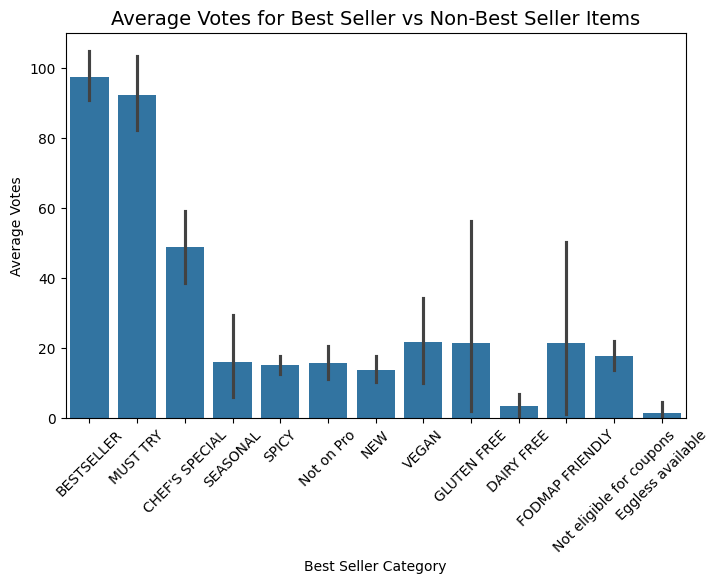

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Best Seller', y='Votes', data=df, estimator='mean')
plt.title("Average Votes for Best Seller vs Non-Best Seller Items", fontsize=14)
plt.xlabel("Best Seller Category")
plt.ylabel("Average Votes")
plt.xticks(rotation=45)
plt.show()

plt.tight_layout()

Analysis of Best Seller tags shows that items labeled as BESTSELLER or MUST TRY consistently attract significantly more customer engagement compared to regular menu items. The median and upper quartile votes for Best Sellers are notably higher, supported by several high-voted outliers. **This indicates that menu labeling positively influences customer choice. Non-Best-Seller items exhibit lower and more stable vote counts, suggesting limited popularity. These results show that restaurants can effectively use Best Seller tags to drive engagement and promote high-margin or high-demand items.**









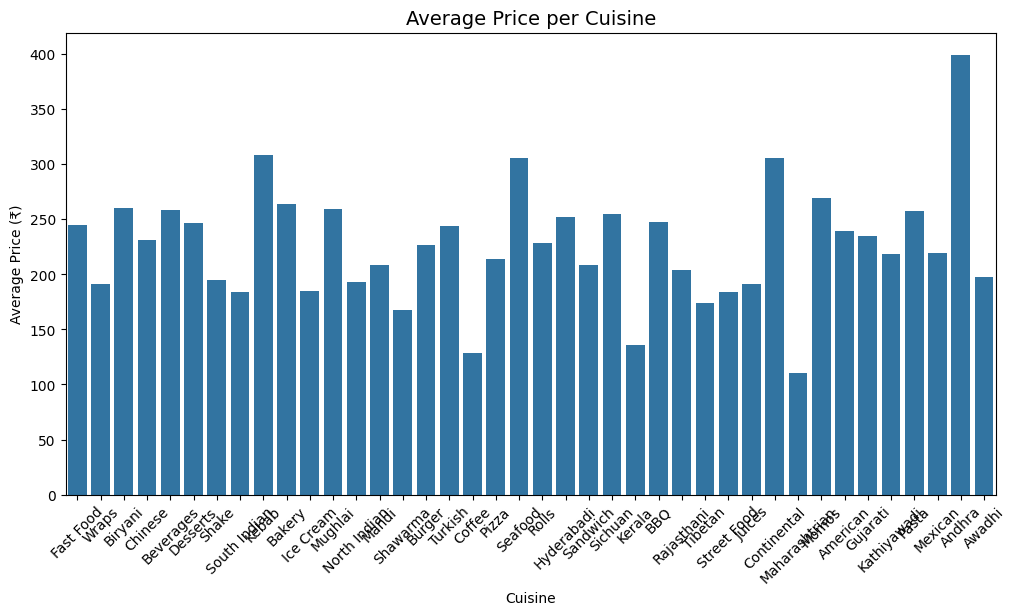

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='Cuisine',
    y='Prices',
    data=df,
    estimator='mean',
    errorbar=None
)
plt.xticks(rotation=45)
plt.title("Average Price per Cuisine", fontsize=14)
plt.xlabel("Cuisine")
plt.ylabel("Average Price (₹)")
plt.show()

plt.tight_layout()

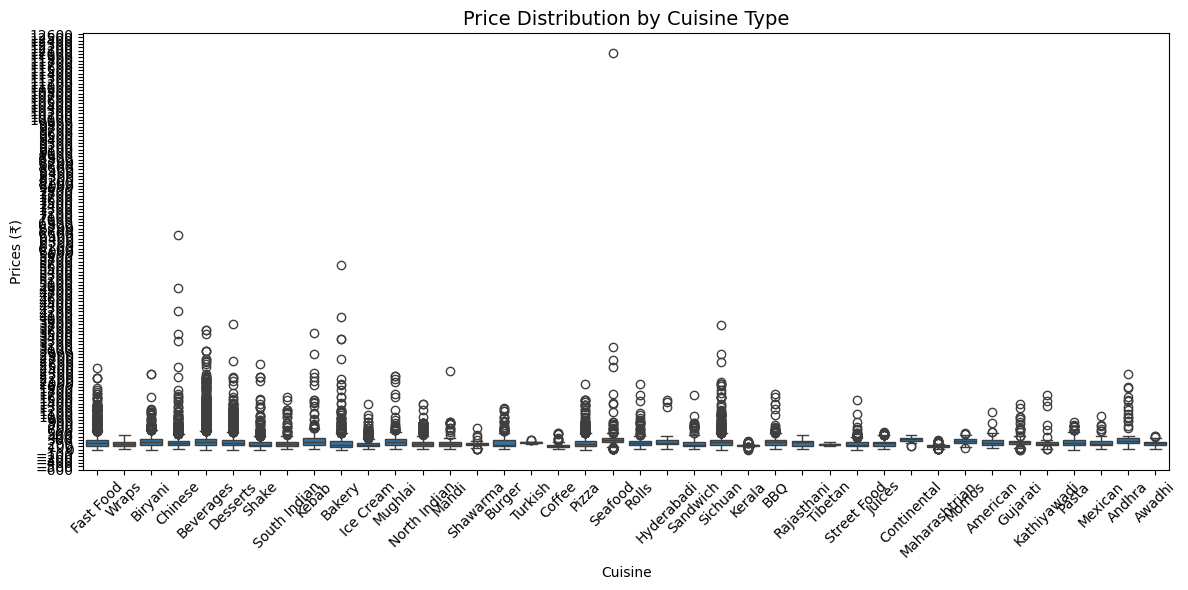

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(12,6))
sns.boxplot(
    x='Cuisine',
    y='Prices',
    data=df
)
plt.xticks(rotation=45)
plt.title("Price Distribution by Cuisine Type", fontsize=14)
plt.xlabel("Cuisine")
plt.ylabel("Prices (₹)")

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(100))

plt.tight_layout()
plt.show()

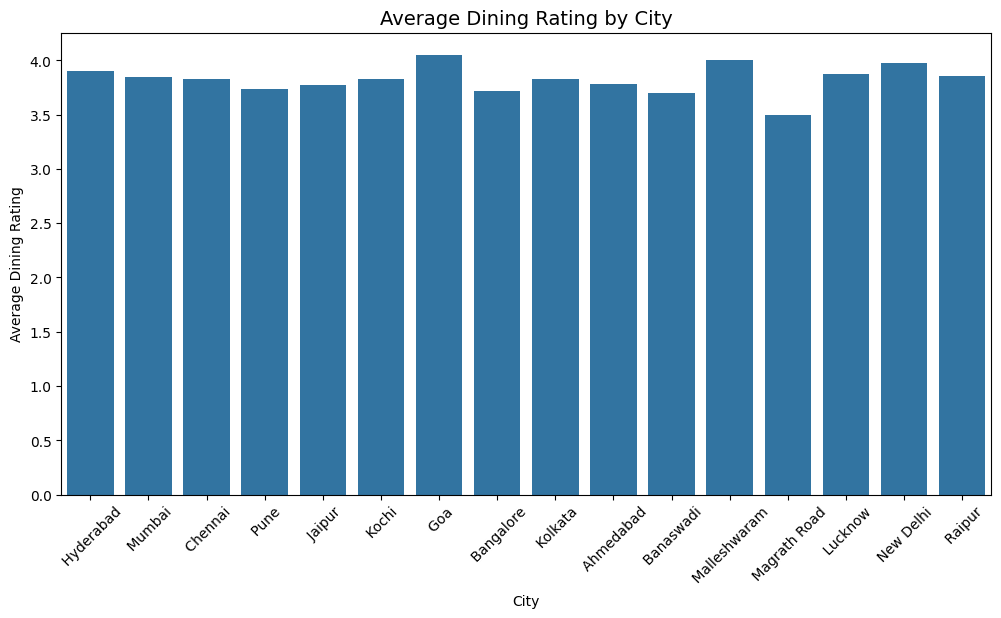

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='City',
    y='Dining Rating',
    data=df,
    estimator='mean',
    errorbar=None
)
plt.xticks(rotation=45)
plt.title("Average Dining Rating by City", fontsize=14)
plt.xlabel("City")
plt.ylabel("Average Dining Rating")
plt.show()


plt.tight_layout()

Top 10 Highest Rated **Places**

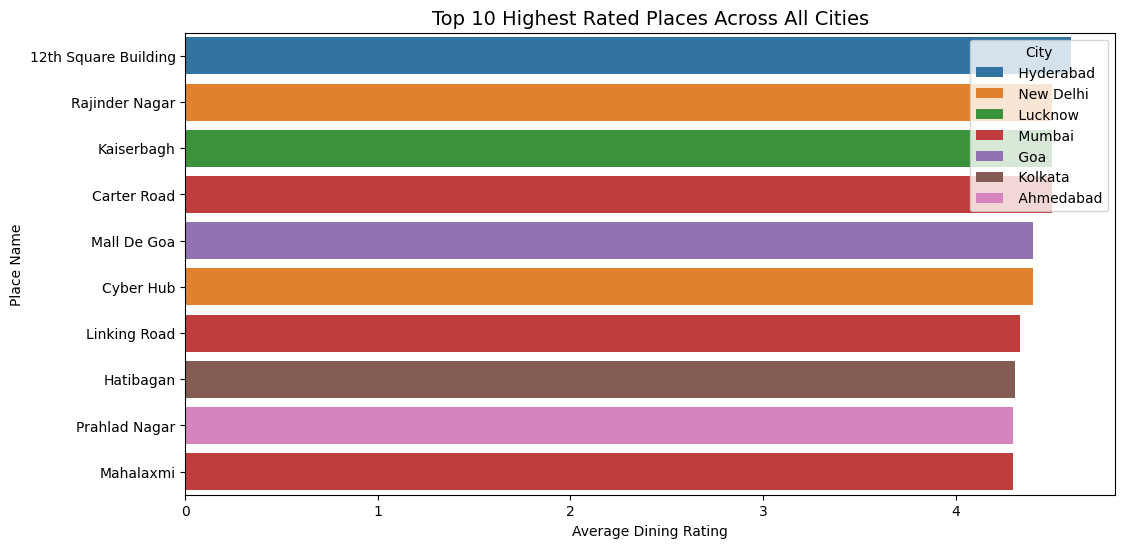

In [ ]:
top_places = df.groupby(['City', 'Place Name'])['Dining Rating'] \
               .mean().reset_index() \
               .sort_values(by='Dining Rating', ascending=False) \
               .head(10)

plt.figure(figsize=(12,6))
sns.barplot(y='Place Name', x='Dining Rating', data=top_places, hue='City')
plt.title("Top 10 Highest Rated Places Across All Cities", fontsize=14)
plt.xlabel("Average Dining Rating")
plt.ylabel("Place Name")
plt.legend(title="City")
plt.show()


plt.tight_layout()

# Correlation Analysis

A heatmap is used to identify relationships between numerical variables.

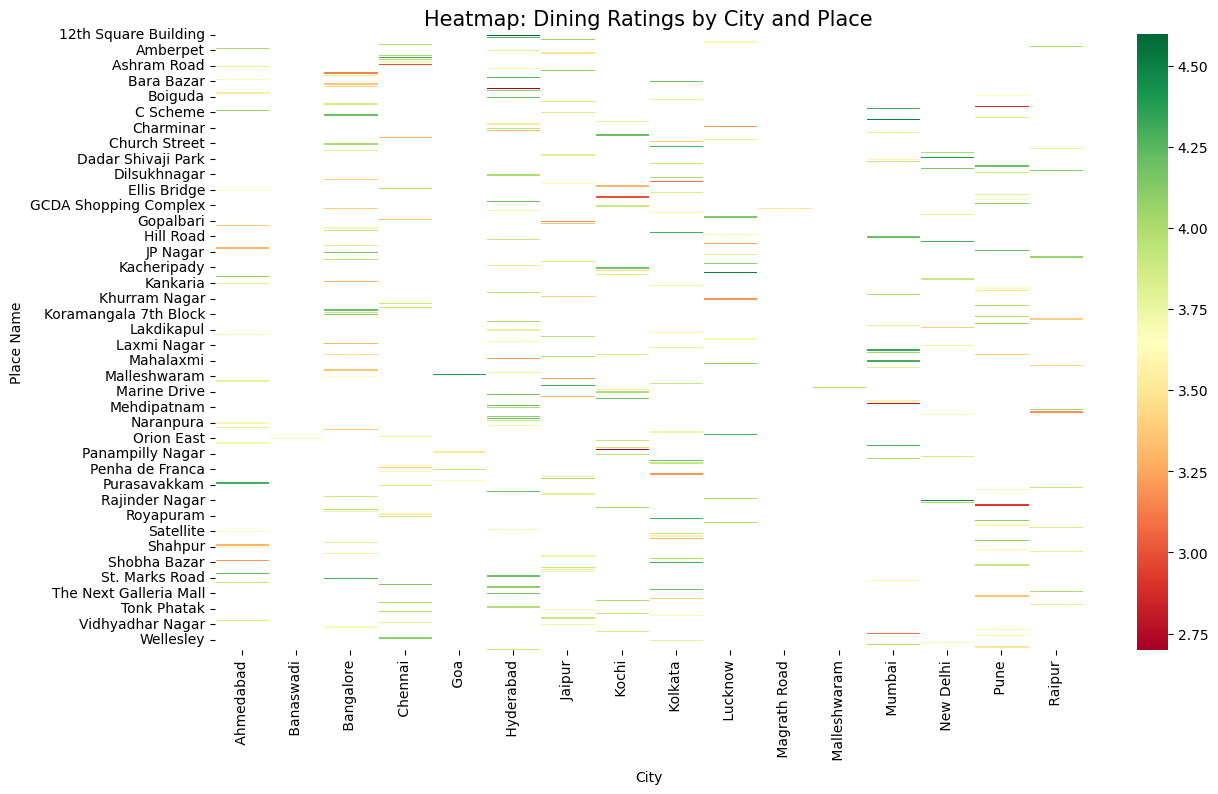

In [ ]:
pivot = df.pivot_table(
    values='Dining Rating',
    index='Place Name',
    columns='City',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, annot=False, cmap='RdYlGn', linewidths=.5)
plt.title("Heatmap: Dining Ratings by City and Place", fontsize=15)
plt.show()


plt.tight_layout()

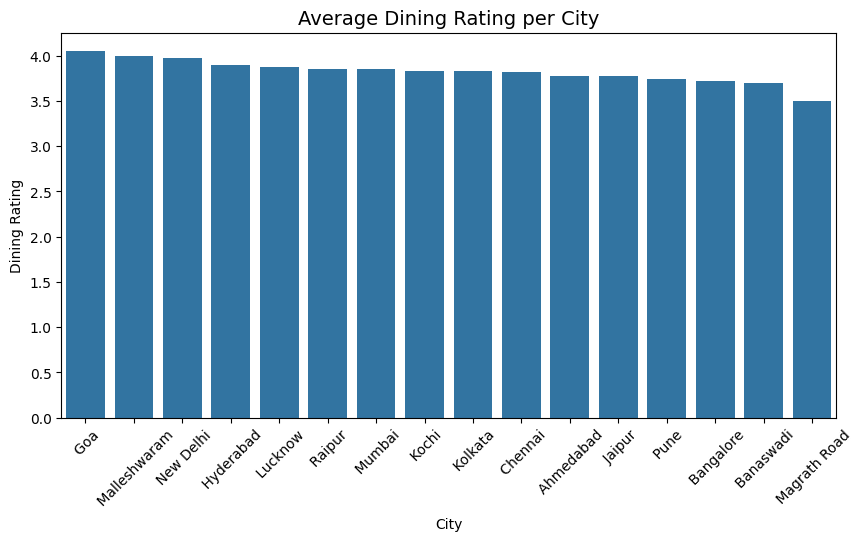

In [ ]:
city_ratings = df.groupby('City')['Dining Rating'].mean().reset_index() \
                 .sort_values(by='Dining Rating', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='City', y='Dining Rating', data=city_ratings)
plt.title("Average Dining Rating per City", fontsize=14)
plt.xticks(rotation=45)
plt.show()


plt.tight_layout()

# Key Business Insights

- Mid-range restaurants dominate customer engagement.
- Bestseller tags significantly improve visibility and customer interaction.
- Certain cuisines attract substantially higher customer attention.
- Ratings show a moderate relationship with customer votes.
- Affordable restaurants receive strong engagement across categories.

# Business Recommendations

## Recommendation 1
Restaurants should focus on affordable and mid-range pricing strategies to maximize customer reach.

## Recommendation 2
Food delivery platforms should promote bestseller items more aggressively to improve engagement and conversions.

## Recommendation 3
Restaurant owners can expand high-performing cuisine offerings based on customer demand patterns.

## Recommendation 4
Restaurants with high ratings but lower visibility should receive recommendation boosts on platforms.

# Conclusion

This project analyzed restaurant and customer behavior data from Zomato using Python-based exploratory data analysis techniques.

The analysis identified important patterns related to:
- pricing trends
- cuisine popularity
- customer engagement
- restaurant ratings

The project demonstrates how data analysis can support business decision-making in the restaurant and food delivery industry.